# PyTorch 기반 나이브 베이즈 알고리즘 적용 SMS 스팸 분류 실습

이 노트북은 PyTorch 기반 Colab 실습 자료입니다.

핵심 흐름은 다음과 같습니다.

1. SMS 데이터 불러오기
2. 텍스트 전처리
3. 문서-단어 행렬(Document Term Matrix, DTM) 생성
4. 훈련 데이터와 테스트 데이터 분리
5. 자주 등장하는 단어만 선택
6. 단어 출현 여부를 Yes/No 형태로 변환
7. 나이브 베이즈 모델 학습
8. 테스트 데이터 예측
9. 혼동행렬과 정확도 평가
10. 라플라스 스무딩으로 성능 개선

여기서는 PyTorch Tensor 연산을 사용하여 Bernoulli Naive Bayes를 직접 구현합니다.

## 0. Colab 실행 환경 준비

Colab에는 대부분의 기본 라이브러리가 설치되어 있습니다.  
데이터셋 다운로드와 압축 해제를 위해 `requests`, `zipfile`을 사용하고, 텍스트 벡터화는 `scikit-learn`의 `CountVectorizer`를 사용합니다.

In [31]:
# ============================================================
# 0. 기본 라이브러리 불러오기
# ============================================================

# 운영체제 경로와 파일 존재 여부를 확인하기 위한 표준 라이브러리입니다.
import os

# 웹에서 데이터 파일을 다운로드하기 위한 라이브러리입니다.
import requests

# zip 압축 파일을 해제하기 위한 표준 라이브러리입니다.
import zipfile

# 문자열 데이터를 다루기 위한 표준 라이브러리입니다.
import io

# 숫자 계산과 배열 처리를 위한 라이브러리입니다.
import numpy as np

# 표 형태의 데이터를 다루기 위한 라이브러리입니다.
import pandas as pd

# 그래프 시각화를 위한 라이브러리입니다.
import matplotlib.pyplot as plt

# PyTorch 핵심 라이브러리입니다.
import torch

# PyTorch 모델 클래스를 만들기 위한 모듈입니다.
import torch.nn as nn

# 텍스트를 문서-단어 행렬로 변환하기 위한 클래스입니다.
from sklearn.feature_extraction.text import CountVectorizer

# 데이터셋을 훈련용과 테스트용으로 분리하기 위한 함수입니다.
from sklearn.model_selection import train_test_split

# 모델 평가를 위한 지표 함수들입니다.
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# 실행 장치를 설정합니다.
# GPU가 있으면 cuda를 사용하고, 없으면 cpu를 사용합니다.
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 실습 결과를 재현하기 위해 난수 시드를 고정합니다.
np.random.seed(42)
torch.manual_seed(42)

print("사용 장치:", device)

사용 장치: cpu


## 1. SMS Spam Collection 데이터 불러오기


Colab에서는 공개 SMS Spam Collection 데이터를 내려받아 사용합니다.

데이터는 두 개의 컬럼으로 구성됩니다.

| 컬럼 | 의미 |
|---|---|
| label | ham 또는 spam |
| text | SMS 문장 |

In [32]:
# ============================================================
# 1. SMS Spam Collection 데이터셋 다운로드 및 로드
# ============================================================

# UCI SMS Spam Collection 데이터셋 zip 파일 주소입니다.
# Colab에서 직접 다운로드하여 실습할 수 있도록 구성했습니다.
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00228/smsspamcollection.zip"

# 다운로드한 zip 파일을 저장할 경로입니다.
zip_path = "smsspamcollection.zip"

# 압축 해제 후 생성되는 원본 텍스트 파일명입니다.
data_file = "SMSSpamCollection"

# 데이터 파일이 아직 없을 때만 다운로드를 수행합니다.
if not os.path.exists(data_file):
    # 웹 주소로부터 zip 파일을 요청합니다.
    response = requests.get(url)

    # 요청이 실패하면 에러를 발생시킵니다.
    response.raise_for_status()

    # 다운로드한 바이너리 내용을 zip 파일로 저장합니다.
    with open(zip_path, "wb") as f:
        f.write(response.content)

    # zip 파일을 현재 작업 폴더에 압축 해제합니다.
    with zipfile.ZipFile(zip_path, "r") as z:
        z.extractall(".")

# 데이터 파일은 탭으로 label과 text가 구분되어 있습니다.
# header=None은 첫 줄을 컬럼명으로 보지 않겠다는 의미입니다.
sms_df = pd.read_csv(
    data_file,
    sep="	",
    header=None,
    names=["label", "text"],
    encoding="latin-1"
)

# 데이터 앞부분을 확인합니다.
print(sms_df.head())

# 전체 데이터 크기를 확인합니다.
print("데이터 크기:", sms_df.shape)

# ham/spam 개수를 확인합니다.
print(sms_df["label"].value_counts())

# ham/spam 비율을 확인합니다.
print(sms_df["label"].value_counts(normalize=True))

  label                                               text
0   ham  Go until jurong point, crazy.. Available only ...
1   ham                      Ok lar... Joking wif u oni...
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...
3   ham  U dun say so early hor... U c already then say...
4   ham  Nah I don't think he goes to usf, he lives aro...
데이터 크기: (5572, 2)
label
ham     4825
spam     747
Name: count, dtype: int64
label
ham     0.865937
spam    0.134063
Name: proportion, dtype: float64


## 2. 라벨 인코딩

나이브 베이즈 모델이 계산하기 쉽도록 문자열 라벨을 숫자로 변환합니다.

| 원래 라벨 | 숫자 라벨 |
|---|---:|
| ham | 0 |
| spam | 1 |

In [33]:
# ============================================================
# 2. 문자열 라벨을 숫자 라벨로 변환
# ============================================================

# ham은 정상 문자이므로 0, spam은 스팸 문자이므로 1로 변환합니다.
sms_df["target"] = sms_df["label"].map({"ham": 0, "spam": 1})

# 변환 결과를 확인합니다.
print(sms_df[["label", "target", "text"]].head())

# 입력 데이터 X는 SMS 문장입니다.
X_text = sms_df["text"].values

# 정답 데이터 y는 숫자로 변환된 라벨입니다.
y = sms_df["target"].values

  label  target                                               text
0   ham       0  Go until jurong point, crazy.. Available only ...
1   ham       0                      Ok lar... Joking wif u oni...
2  spam       1  Free entry in 2 a wkly comp to win FA Cup fina...
3   ham       0  U dun say so early hor... U c already then say...
4   ham       0  Nah I don't think he goes to usf, he lives aro...


## 3. 훈련 데이터와 테스트 데이터 분리

앞쪽 75%를 훈련 데이터, 뒤쪽 25%를 테스트 데이터로 사용했습니다.  
여기서는 `train_test_split()`을 사용하여 75:25 비율로 나누고, `stratify=y`를 적용하여 ham/spam 비율이 비슷하게 유지되도록 합니다.

In [34]:
# ============================================================
# 3. 훈련 데이터와 테스트 데이터 분리
# ============================================================

# test_size=0.25는 전체 데이터의 25%를 테스트 데이터로 사용한다는 의미입니다.
# stratify=y는 훈련/테스트 데이터의 클래스 비율을 원본과 비슷하게 유지합니다.
X_train_text, X_test_text, y_train, y_test = train_test_split(
    X_text,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

# 분리된 데이터 크기를 확인합니다.
print("훈련 문장 수:", len(X_train_text))
print("테스트 문장 수:", len(X_test_text))

# 훈련 데이터의 클래스 비율을 확인합니다.
print("훈련 라벨 비율:")
print(pd.Series(y_train).value_counts(normalize=True).sort_index())

# 테스트 데이터의 클래스 비율을 확인합니다.
print("테스트 라벨 비율:")
print(pd.Series(y_test).value_counts(normalize=True).sort_index())

훈련 문장 수: 4179
테스트 문장 수: 1393
훈련 라벨 비율:
0    0.865997
1    0.134003
Name: proportion, dtype: float64
테스트 라벨 비율:
0    0.865757
1    0.134243
Name: proportion, dtype: float64


## 4. 문서-단어 행렬 생성

Python에서는 `CountVectorizer`를 사용합니다.

중요 옵션은 다음과 같습니다.

| 옵션 | 의미 |
|---|---|
| lowercase=True | 모든 단어를 소문자로 변환 |
| stop_words="english" | 영어 불용어 제거 |
| token_pattern | 단어 토큰 규칙 지정 |
| min_df=7 | 최소 7개 문서 이상에 등장한 단어만 사용 |

`min_df=7`을 적용합니다.

In [35]:
# ============================================================
# 4. 텍스트를 문서-단어 행렬로 변환
# ============================================================

# CountVectorizer는 텍스트 문장을 숫자 행렬로 바꾸는 도구입니다.
# binary=True는 단어 빈도 수가 아니라 단어 출현 여부만 0/1로 저장하겠다는 의미입니다.
# Bernoulli Naive Bayes는 단어가 등장했는지 여부를 사용하므로 binary=True가 적합합니다.
vectorizer = CountVectorizer(
    lowercase=True,              # 모든 문자를 소문자로 변환합니다.
    stop_words="english",       # 영어 불용어를 제거합니다.
    token_pattern=r"(?u)\b[a-zA-Z][a-zA-Z]+\b",  # 영문자 2글자 이상 단어만 사용합니다.
    min_df=7,                    # 최소 7개 문서 이상에 등장한 단어만 사용합니다.
    binary=True                  # 단어 출현 여부만 0/1로 기록합니다.
)

# 훈련 데이터로 단어 사전을 학습하고 문서-단어 행렬을 만듭니다.
X_train_sparse = vectorizer.fit_transform(X_train_text)

# 테스트 데이터는 훈련 데이터에서 만든 단어 사전을 기준으로 변환합니다.
X_test_sparse = vectorizer.transform(X_test_text)

# 생성된 단어 목록을 가져옵니다.
feature_names = vectorizer.get_feature_names_out()

# 문서-단어 행렬의 크기를 확인합니다.
print("훈련 DTM 크기:", X_train_sparse.shape)
print("테스트 DTM 크기:", X_test_sparse.shape)
print("사용 단어 수:", len(feature_names))
print("단어 예시:", feature_names[:30])

훈련 DTM 크기: (4179, 883)
테스트 DTM 크기: (1393, 883)
사용 단어 수: 883
단어 예시: ['abiola' 'able' 'abt' 'ac' 'account' 'actually' 'add' 'address' 'aft'
 'afternoon' 'age' 'ago' 'ah' 'aha' 'aight' 'alex' 'alright' 'amp' 'angry'
 'ans' 'answer' 'anymore' 'anytime' 'apply' 'ard' 'asap' 'ask' 'askd'
 'asked' 'asking']


## 5. PyTorch Tensor 변환

`CountVectorizer`의 결과는 희소 행렬(sparse matrix)입니다.  
밀집 배열(dense array)로 변환한 뒤 PyTorch Tensor로 변환합니다.

데이터가 매우 큰 실제 프로젝트에서는 희소 행렬을 그대로 활용하는 방식이 더 효율적입니다.

In [36]:
# ============================================================
# 5. NumPy 배열과 PyTorch Tensor로 변환
# ============================================================

# sparse matrix를 NumPy dense array로 변환합니다.
# 각 값은 단어가 없으면 0, 있으면 1입니다.
X_train_np = X_train_sparse.toarray().astype(np.float32)
X_test_np = X_test_sparse.toarray().astype(np.float32)

# y 라벨을 NumPy 배열로 변환합니다.
y_train_np = y_train.astype(np.int64)
y_test_np = y_test.astype(np.int64)

# NumPy 배열을 PyTorch Tensor로 변환합니다.
# X는 실수형 float32로 변환합니다.
X_train_tensor = torch.tensor(X_train_np, dtype=torch.float32).to(device)
X_test_tensor = torch.tensor(X_test_np, dtype=torch.float32).to(device)

# y는 클래스 번호이므로 정수형 long으로 변환합니다.
y_train_tensor = torch.tensor(y_train_np, dtype=torch.long).to(device)
y_test_tensor = torch.tensor(y_test_np, dtype=torch.long).to(device)

# Tensor 크기를 확인합니다.
print("X_train_tensor:", X_train_tensor.shape)
print("X_test_tensor:", X_test_tensor.shape)
print("y_train_tensor:", y_train_tensor.shape)
print("y_test_tensor:", y_test_tensor.shape)

X_train_tensor: torch.Size([4179, 883])
X_test_tensor: torch.Size([1393, 883])
y_train_tensor: torch.Size([4179])
y_test_tensor: torch.Size([1393])


## 6. PyTorch로 Bernoulli Naive Bayes 클래스 구현

SMS 스팸 분류에서는 단어 빈도보다 단어 존재 여부가 중요할 수 있습니다.  
따라서 여기서는 `Bernoulli Naive Bayes`를 직접 구현합니다.

핵심 아이디어는 다음과 같습니다.

1. 각 클래스의 사전확률 `P(class)` 계산
2. 각 클래스에서 각 단어가 등장할 조건부확률 `P(word=1 | class)` 계산
3. 새 문장에 대해 각 클래스의 로그확률 계산
4. 로그확률이 가장 큰 클래스로 예측

라플라스 스무딩은 확률이 0이 되는 문제를 방지합니다.

In [37]:
# ============================================================
# 6. PyTorch 기반 Bernoulli Naive Bayes 모델 클래스 정의
# ============================================================

class TorchBernoulliNaiveBayes(nn.Module):
    """
    PyTorch Tensor 연산으로 구현한 Bernoulli Naive Bayes 분류기입니다.

    Bernoulli Naive Bayes는 각 단어의 출현 여부를 0/1로 보고 분류합니다.
    예를 들어 특정 SMS에 'free'라는 단어가 있으면 1, 없으면 0으로 표현합니다.
    """

    def __init__(self, num_features, num_classes=2, laplace=0.0):
        """
        모델 초기화 메서드입니다.

        Parameters
        ----------
        num_features : int
            단어 사전의 크기입니다. 즉, DTM의 컬럼 수입니다.
        num_classes : int
            분류할 클래스 개수입니다. 여기서는 ham/spam 2개입니다.
        laplace : float
            라플라스 스무딩 값입니다. 0이면 스무딩을 사용하지 않습니다.
        """
        # nn.Module의 초기화 기능을 실행합니다.
        super().__init__()

        # 입력 특성 수를 저장합니다.
        self.num_features = num_features

        # 클래스 개수를 저장합니다.
        self.num_classes = num_classes

        # 라플라스 스무딩 값을 저장합니다.
        self.laplace = laplace

        # 클래스 사전확률 log P(class)를 저장할 버퍼입니다.
        # register_buffer는 학습 파라미터는 아니지만 모델과 함께 device 이동/저장이 되도록 합니다.
        self.register_buffer("class_log_prior_", torch.zeros(num_classes))

        # 단어 등장 조건부확률 log P(word=1 | class)를 저장합니다.
        self.register_buffer("feature_log_prob_", torch.zeros(num_classes, num_features))

        # 단어 미등장 조건부확률 log P(word=0 | class)를 저장합니다.
        self.register_buffer("feature_log_neg_prob_", torch.zeros(num_classes, num_features))

    def fit(self, X, y):
        """
        나이브 베이즈 확률을 계산하는 학습 메서드입니다.

        X : shape = [문서 수, 단어 수]
            단어 출현 여부가 0 또는 1로 들어있는 Tensor입니다.
        y : shape = [문서 수]
            각 문서의 정답 클래스 번호입니다.
        """
        # 기울기 계산이 필요 없는 확률 계산 과정입니다.
        with torch.no_grad():
            # 각 클래스별 문서 개수를 담을 리스트입니다.
            class_count_list = []

            # 각 클래스별 단어 출현 개수를 담을 리스트입니다.
            feature_count_list = []

            # 클래스 0부터 num_classes-1까지 반복합니다.
            for c in range(self.num_classes):
                # 현재 클래스 c에 해당하는 문서만 True가 되는 마스크를 만듭니다.
                class_mask = (y == c)

                # 현재 클래스에 속한 문서만 선택합니다.
                X_c = X[class_mask]

                # 현재 클래스의 문서 개수를 계산합니다.
                class_count = X_c.shape[0]

                # 현재 클래스에서 각 단어가 등장한 문서 수를 계산합니다.
                # Bernoulli 방식이므로 단어 빈도 합이 아니라 0/1 출현 횟수 합입니다.
                feature_count = X_c.sum(dim=0)

                # 결과를 리스트에 저장합니다.
                class_count_list.append(class_count)
                feature_count_list.append(feature_count)

            # 클래스별 문서 개수를 Tensor로 변환합니다.
            class_count_tensor = torch.tensor(
                class_count_list,
                dtype=torch.float32,
                device=X.device
            )

            # 클래스별 단어 출현 개수를 Tensor로 쌓습니다.
            feature_count_tensor = torch.stack(feature_count_list, dim=0)

            # 전체 문서 수를 계산합니다.
            total_count = class_count_tensor.sum()

            # 클래스 사전확률 P(class)를 로그로 계산합니다.
            # 로그를 사용하는 이유는 많은 확률을 곱할 때 값이 0에 가까워지는 언더플로를 막기 위해서입니다.
            self.class_log_prior_ = torch.log(class_count_tensor / total_count)

            # 라플라스 스무딩 값을 Tensor 계산에 사용할 수 있도록 변수로 둡니다.
            alpha = self.laplace

            # Bernoulli Naive Bayes의 조건부확률을 계산합니다.
            # P(word=1 | class) = (해당 클래스에서 단어가 등장한 문서 수 + alpha) / (해당 클래스 문서 수 + 2*alpha)
            # 2*alpha를 더하는 이유는 Bernoulli 값이 0 또는 1 두 가지 경우를 갖기 때문입니다.
            prob = (feature_count_tensor + alpha) / (class_count_tensor.view(-1, 1) + 2 * alpha)

            # laplace=0일 때 어떤 단어 확률이 정확히 0 또는 1이 되면 log(0) 문제가 발생할 수 있습니다.
            # 아주 작은 값 eps로 확률 범위를 제한하여 계산 오류를 방지합니다.
            eps = 1e-12
            prob = torch.clamp(prob, eps, 1.0 - eps)

            # 단어가 등장할 로그확률 log P(word=1 | class)를 저장합니다.
            self.feature_log_prob_ = torch.log(prob)

            # 단어가 등장하지 않을 로그확률 log P(word=0 | class)를 저장합니다.
            self.feature_log_neg_prob_ = torch.log(1.0 - prob)

        # fit 후 자기 자신을 반환하면 sklearn과 비슷한 사용 방식이 가능합니다.
        return self

    def forward(self, X):
        """
        각 클래스에 대한 로그확률 점수를 계산합니다.

        반환값 shape = [문서 수, 클래스 수]
        """
        # 단어가 존재하는 경우의 로그확률 합입니다.
        # X가 1이면 log P(word=1 | class)가 반영됩니다.
        positive_log_prob = X @ self.feature_log_prob_.T

        # 단어가 존재하지 않는 경우의 로그확률 합입니다.
        # 1-X가 1이면 log P(word=0 | class)가 반영됩니다.
        negative_log_prob = (1.0 - X) @ self.feature_log_neg_prob_.T

        # 클래스 사전확률과 조건부확률을 더하여 최종 로그 점수를 계산합니다.
        log_scores = self.class_log_prior_ + positive_log_prob + negative_log_prob

        # 각 문서에 대한 클래스별 로그 점수를 반환합니다.
        return log_scores

    def predict(self, X):
        """
        가장 로그확률이 큰 클래스를 예측합니다.
        """
        # forward()를 호출하여 클래스별 로그 점수를 계산합니다.
        log_scores = self.forward(X)

        # dim=1 방향에서 가장 큰 값을 가진 클래스 번호를 선택합니다.
        predicted_class = torch.argmax(log_scores, dim=1)

        # 예측 클래스 번호를 반환합니다.
        return predicted_class

    def predict_proba(self, X):
        """
        클래스별 예측 확률을 반환합니다.
        """
        # 클래스별 로그 점수를 계산합니다.
        log_scores = self.forward(X)

        # 로그 점수를 softmax에 넣어 확률 형태로 변환합니다.
        probabilities = torch.softmax(log_scores, dim=1)

        # 클래스별 확률을 반환합니다.
        return probabilities

## 7. 나이브 베이즈 모델 학습

먼저 라플라스 스무딩을 0으로 두고 학습합니다.  

In [38]:
# ============================================================
# 7. 라플라스 스무딩 없는 Naive Bayes 모델 학습
# ============================================================

# 입력 특성 수는 문서-단어 행렬의 컬럼 수입니다.
num_features = X_train_tensor.shape[1]

# ham/spam 2개 클래스 분류이므로 num_classes=2입니다.
num_classes = 2

# laplace=0.0은 라플라스 스무딩을 사용하지 않는 설정입니다.
nb_model = TorchBernoulliNaiveBayes(
    num_features=num_features,
    num_classes=num_classes,
    laplace=0.0
).to(device)

# fit() 메서드로 클래스별 사전확률과 단어별 조건부확률을 계산합니다.
nb_model.fit(X_train_tensor, y_train_tensor)

# 모델 내부에 저장된 클래스 사전확률을 확인합니다.
print("클래스 로그 사전확률 log P(class):")
print(nb_model.class_log_prior_)

# 확률로 변환해서 해석하기 쉽게 출력합니다.
print("클래스 사전확률 P(class):")
print(torch.exp(nb_model.class_log_prior_))

클래스 로그 사전확률 log P(class):
tensor([-0.1439, -2.0099])
클래스 사전확률 P(class):
tensor([0.8660, 0.1340])


## 8. 모델 예측 및 성능 평가

여기서는 정확도, 혼동행렬, 분류 리포트를 출력합니다.

In [39]:
# ============================================================
# 8. 테스트 데이터 예측 및 평가
# ============================================================

# 평가 단계에서는 기울기 계산이 필요 없으므로 torch.no_grad()를 사용합니다.
with torch.no_grad():
    # 테스트 데이터의 예측 클래스 번호를 계산합니다.
    y_pred_tensor = nb_model.predict(X_test_tensor)

    # 클래스별 예측 확률도 계산합니다.
    y_proba_tensor = nb_model.predict_proba(X_test_tensor)

# Tensor를 CPU의 NumPy 배열로 변환합니다.
y_pred = y_pred_tensor.cpu().numpy()
y_proba = y_proba_tensor.cpu().numpy()

# 정확도를 계산합니다.
accuracy = accuracy_score(y_test_np, y_pred)

# 혼동행렬을 계산합니다.
cm = confusion_matrix(y_test_np, y_pred)

# 평가 결과를 출력합니다.
print("정확도 Accuracy:", accuracy)
print("혼동행렬 Confusion Matrix:")
print(cm)

# 클래스 이름을 지정합니다.
target_names = ["ham", "spam"]

# 정밀도, 재현율, F1-score를 출력합니다.
print("분류 리포트 Classification Report:")
print(classification_report(y_test_np, y_pred, target_names=target_names))

정확도 Accuracy: 0.9806173725771715
혼동행렬 Confusion Matrix:
[[1202    4]
 [  23  164]]
분류 리포트 Classification Report:
              precision    recall  f1-score   support

         ham       0.98      1.00      0.99      1206
        spam       0.98      0.88      0.92       187

    accuracy                           0.98      1393
   macro avg       0.98      0.94      0.96      1393
weighted avg       0.98      0.98      0.98      1393



## 9. 혼동행렬 시각화

혼동행렬은 실제값과 예측값의 관계를 보여줍니다.

| 구분 | 의미 |
|---|---|
| TN | 실제 ham을 ham으로 예측 |
| FP | 실제 ham을 spam으로 잘못 예측 |
| FN | 실제 spam을 ham으로 잘못 예측 |
| TP | 실제 spam을 spam으로 예측 |

스팸 필터에서는 정상 문자를 스팸으로 잘못 분류하는 FP도 중요하고, 스팸 문자를 정상으로 놓치는 FN도 중요합니다.

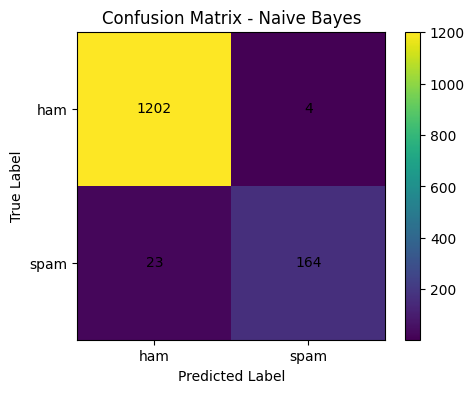

In [40]:
# ============================================================
# 9. 혼동행렬 시각화
# ============================================================

# 그래프 크기를 설정합니다.
plt.figure(figsize=(5, 4))

# 혼동행렬을 이미지 형태로 표시합니다.
plt.imshow(cm)

# 그래프 제목을 설정합니다.
plt.title("Confusion Matrix - Naive Bayes")

# x축과 y축 눈금 이름을 설정합니다.
plt.xticks([0, 1], target_names)
plt.yticks([0, 1], target_names)

# x축과 y축 라벨을 설정합니다.
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

# 각 칸에 숫자를 표시합니다.
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center")

# 색상 막대를 표시합니다.
plt.colorbar()

# 그래프를 출력합니다.
plt.show()

## 10. 라플라스 스무딩으로 성능 개선

라플라스 스무딩은 어떤 단어가 특정 클래스(카테고리)에서 한 번도 등장하지 않았을 때 확률이 0이 되는 문제를 줄입니다.

In [41]:
# ============================================================
# 10. 라플라스 스무딩 적용 모델 학습 및 평가
# ============================================================

# laplace=0.1은 개선 실험입니다.
nb_model_laplace = TorchBernoulliNaiveBayes(
    num_features=num_features,
    num_classes=num_classes,
    laplace=0.1
).to(device)

# 라플라스 스무딩을 적용하여 모델을 학습합니다.
nb_model_laplace.fit(X_train_tensor, y_train_tensor)

# 테스트 데이터 예측을 수행합니다.
with torch.no_grad():
    y_pred_laplace_tensor = nb_model_laplace.predict(X_test_tensor)
    y_proba_laplace_tensor = nb_model_laplace.predict_proba(X_test_tensor)

# Tensor를 NumPy 배열로 변환합니다.
y_pred_laplace = y_pred_laplace_tensor.cpu().numpy()
y_proba_laplace = y_proba_laplace_tensor.cpu().numpy()

# 정확도와 혼동행렬을 계산합니다.
accuracy_laplace = accuracy_score(y_test_np, y_pred_laplace)
cm_laplace = confusion_matrix(y_test_np, y_pred_laplace)

# 결과를 출력합니다.
print("라플라스 스무딩 적용 정확도 Accuracy:", accuracy_laplace)
print("라플라스 스무딩 적용 혼동행렬:")
print(cm_laplace)
print("라플라스 스무딩 적용 분류 리포트:")
print(classification_report(y_test_np, y_pred_laplace, target_names=target_names))

라플라스 스무딩 적용 정확도 Accuracy: 0.9834888729361091
라플라스 스무딩 적용 혼동행렬:
[[1202    4]
 [  19  168]]
라플라스 스무딩 적용 분류 리포트:
              precision    recall  f1-score   support

         ham       0.98      1.00      0.99      1206
        spam       0.98      0.90      0.94       187

    accuracy                           0.98      1393
   macro avg       0.98      0.95      0.96      1393
weighted avg       0.98      0.98      0.98      1393



## 11. 스무딩 전후 성능 비교

라플라스 스무딩을 적용하기 전과 후의 정확도와 오류 개수를 비교합니다.

                     model  accuracy  error_count
0  Naive Bayes laplace=0.0  0.980617           27
1  Naive Bayes laplace=0.1  0.983489           23


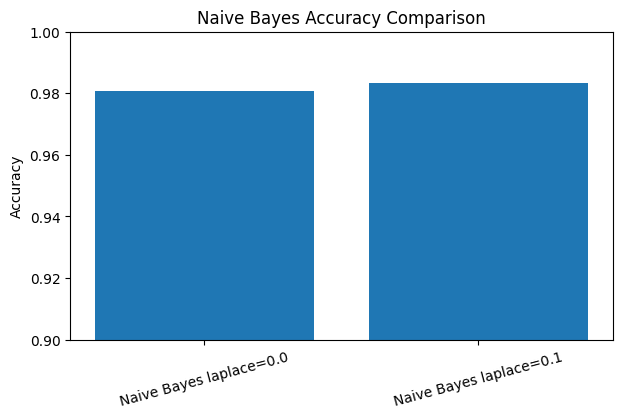

In [42]:
# ============================================================
# 11. 스무딩 전후 성능 비교
# ============================================================

# 스무딩 전 오분류 개수를 계산합니다.
error_count = np.sum(y_test_np != y_pred)

# 스무딩 후 오분류 개수를 계산합니다.
error_count_laplace = np.sum(y_test_np != y_pred_laplace)

# 비교 결과를 DataFrame으로 정리합니다.
comparison_df = pd.DataFrame({
    "model": ["Naive Bayes laplace=0.0", "Naive Bayes laplace=0.1"],
    "accuracy": [accuracy, accuracy_laplace],
    "error_count": [error_count, error_count_laplace]
})

# 비교표를 출력합니다.
print(comparison_df)

# 정확도 막대그래프를 그립니다.
plt.figure(figsize=(7, 4))
plt.bar(comparison_df["model"], comparison_df["accuracy"])
plt.ylim(0.9, 1.0)
plt.ylabel("Accuracy")
plt.title("Naive Bayes Accuracy Comparison")
plt.xticks(rotation=15)
plt.show()

## 12. 새 SMS 문장 예측

학습된 모델을 사용하여 새로운 문자 메시지가 ham인지 spam인지 예측합니다.

In [43]:
# ============================================================
# 12. 새 문자 메시지 예측 함수 만들기
# ============================================================

def predict_sms(model, messages):
    """
    새로운 SMS 문장을 ham/spam으로 예측하는 함수입니다.

    Parameters
    ----------
    model : TorchBernoulliNaiveBayes
        학습된 나이브 베이즈 모델입니다.
    messages : list[str]
        예측할 SMS 문장 리스트입니다.
    """
    # 학습 때 사용한 vectorizer로 새 문장을 같은 단어 사전 기준으로 변환합니다.
    X_new_sparse = vectorizer.transform(messages)

    # sparse matrix를 dense NumPy 배열로 변환합니다.
    X_new_np = X_new_sparse.toarray().astype(np.float32)

    # NumPy 배열을 PyTorch Tensor로 변환합니다.
    X_new_tensor = torch.tensor(X_new_np, dtype=torch.float32).to(device)

    # 예측을 수행합니다.
    with torch.no_grad():
        pred_tensor = model.predict(X_new_tensor)
        proba_tensor = model.predict_proba(X_new_tensor)

    # Tensor 결과를 NumPy 배열로 변환합니다.
    pred = pred_tensor.cpu().numpy()
    proba = proba_tensor.cpu().numpy()

    # 숫자 라벨을 문자 라벨로 변환하기 위한 딕셔너리입니다.
    label_map = {0: "ham", 1: "spam"}

    # 결과를 저장할 리스트입니다.
    results = []

    # 각 메시지별 예측 결과를 정리합니다.
    for msg, p, prob in zip(messages, pred, proba):
        results.append({
            "message": msg,
            "predicted_label": label_map[int(p)],
            "ham_probability": prob[0],
            "spam_probability": prob[1]
        })

    # 결과를 DataFrame으로 반환합니다.
    return pd.DataFrame(results)


# 예측할 새 SMS 문장 예시입니다.
new_messages = [
    "Congratulations! You won a free ticket. Call now to claim your prize.",
    "Are we still meeting for lunch tomorrow?",
    "URGENT! Your mobile number has been selected for a cash reward.",
    "Please call me when you arrive home."
]

# 라플라스 스무딩을 적용한 모델로 예측합니다.
result_df = predict_sms(nb_model_laplace, new_messages)

# 예측 결과를 출력합니다.
print(result_df)

                                             message predicted_label  \
0  Congratulations! You won a free ticket. Call n...            spam   
1           Are we still meeting for lunch tomorrow?             ham   
2  URGENT! Your mobile number has been selected f...            spam   
3               Please call me when you arrive home.             ham   

   ham_probability  spam_probability  
0     6.146169e-10      1.000000e+00  
1     9.999995e-01      5.039859e-07  
2     5.846606e-08      1.000000e+00  
3     9.999050e-01      9.500382e-05  


## 13. 주요 단어별 조건부확률 확인

나이브 베이즈는 각 클래스(카테고리)에서 어떤 단어가 많이 등장하는지 확률로 확인할 수 있습니다.  
여기서는 spam 클래스(카테고리)에서 조건부확률이 높은 단어들을 출력합니다.

In [44]:
# ============================================================
# 13. 클래스별 주요 단어 확인
# ============================================================

# 라플라스 모델에서 단어 등장 조건부확률 log P(word=1 | class)를 가져옵니다.
feature_log_prob = nb_model_laplace.feature_log_prob_.detach().cpu().numpy()

# 로그확률을 일반 확률로 변환합니다.
feature_prob = np.exp(feature_log_prob)

# spam 클래스는 1번 클래스입니다.
spam_word_prob = feature_prob[1]

# ham 클래스는 0번 클래스입니다.
ham_word_prob = feature_prob[0]

# spam에서 확률이 높은 단어 인덱스 상위 20개를 찾습니다.
top_spam_idx = np.argsort(spam_word_prob)[-20:][::-1]

# ham에서 확률이 높은 단어 인덱스 상위 20개를 찾습니다.
top_ham_idx = np.argsort(ham_word_prob)[-20:][::-1]

# 결과를 표로 정리합니다.
top_words_df = pd.DataFrame({
    "top_spam_words": feature_names[top_spam_idx],
    "spam_probability": spam_word_prob[top_spam_idx],
    "top_ham_words": feature_names[top_ham_idx],
    "ham_probability": ham_word_prob[top_ham_idx]
})

# 주요 단어 표를 출력합니다.
print(top_words_df)

   top_spam_words  spam_probability top_ham_words  ham_probability
0            free          0.221528          just         0.057499
1             txt          0.210818            ll         0.055012
2              ur          0.153695            ok         0.053631
3           claim          0.144770            gt         0.051144
4            text          0.139414            lt         0.050591
5          mobile          0.137629           got         0.049486
6             www          0.135844          know         0.046447
7            stop          0.134059          come         0.045618
8           reply          0.132274          good         0.045342
9             won          0.101928           day         0.041750
10          prize          0.101928            ur         0.041197
11           send          0.096573          like         0.040092
12           just          0.096573          want         0.036223
13           cash          0.093002          love         0.03

In [46]:
# ============================================================
# 가장 많이 혼동되는 단어 순서대로 정렬
# ============================================================

# featurelogprob: (class, vocab) 형태의 log P(word=1 | class)
# featurelognegprob: (class, vocab) 형태의 log P(word=0 | class)

# 두 클래스에서의 차이가 작을수록 더 혼동되는 단어
confusion_score = np.abs(spam_word_prob - ham_word_prob)

confusion_df = pd.DataFrame({
    "word": feature_names,
    "ham_word_prob": ham_word_prob,
    "spam_word_prob": spam_word_prob,
    "abs_diff": confusion_score
})

# 가장 혼동되는 순서: abs_diff가 작은 순서
confusion_df = confusion_df.sort_values(["abs_diff", "word"], ascending=[True, True]).reset_index(drop=True)

print(confusion_df.head(30))

          word  ham_word_prob  spam_word_prob  abs_diff
0     download       0.001962        0.001964  0.000002
1         fact       0.001962        0.001964  0.000002
2   interested       0.001962        0.001964  0.000002
3           mr       0.001962        0.001964  0.000002
4         pete       0.001962        0.001964  0.000002
5         slow       0.001962        0.001964  0.000002
6           ve       0.017987        0.018029  0.000042
7         post       0.003620        0.003749  0.000129
8      believe       0.003896        0.003749  0.000147
9    christmas       0.002238        0.001964  0.000274
10         hit       0.002238        0.001964  0.000274
11       knows       0.002238        0.001964  0.000274
12      listen       0.002238        0.001964  0.000274
13        lose       0.002238        0.001964  0.000274
14         met       0.002238        0.001964  0.000274
15      simple       0.002238        0.001964  0.000274
16       sound       0.002238        0.001964  0